In [2]:
# The aim of the assignment is to simulate the BB84 key distribution protocol.
# This notebook is for a simulation of the protocol with an attacker, to demonstrate that the attacker can be detected.
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.visualization import plot_histogram
from qiskit.circuit import ControlledGate
import math

backend = BasicSimulator()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 44.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 81.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 78.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 4.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=685a73c6d8c505a7e3eac860a807d005350a499617d3e870e6edbc4688fef243
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


In [3]:
def make_random_bit(backend):
  """
  Generate a single random bit using quantum measurement:
  prepare (|0> + |1>)/sqrt(2) with H, then measure.
  """
  qc = QuantumCircuit(1, 1)
  qc.h(0)
  qc.measure(0, 0)

  tqc = transpile(qc, backend)
  result = backend.run(tqc, shots=1).result()
  counts = result.get_counts()
  bit_str = max(counts, key=counts.get)
  return int(bit_str)

def quantum_random_bits(n, backend):
  """
  Generate n random bits using repeated quantum measurements.
  """
  return [make_random_bit(backend) for _ in range(n)]

sample_bits = quantum_random_bits(10, backend)
print("Sample quantum random bits:",sample_bits)

Sample quantum random bits: [0, 0, 0, 0, 1, 1, 1, 1, 0, 0]


In [4]:
def eve_intercept_and_resend(alice_bit, alice_basis, eve_basis, bob_basis, backend):
  """
  Simulate one qubit under an intercept-resend attack.

  alice_bit   : 0 or 1 (Alice's data bit)
  alice_basis : 0 (Z basis) or 1 (X basis)
  eve_basis   : 0 (Z basis) or 1 (X basis)
  bob_basis   : 0 (Z basis) or 1 (X basis)

  Returns:
      eve_bit : Eve's measurement result (0 or 1)
      bob_bit : Bob's measurement result (0 or 1) after Eve's attack
  """

  # Stage 1: Alice encodes and sends qubit to Eve
  qc1 = QuantumCircuit(1, 1)

  if alice_bit == 1:
      qc1.x(0)
  if alice_basis == 1:
      qc1.h(0)

  # Eve intercepts: measure in her chosen basis
  if eve_basis == 1:
      qc1.h(0)

  qc1.measure(0, 0)

  tqc1 = transpile(qc1, backend)
  result1 = backend.run(tqc1, shots=1).result()
  counts1 = result1.get_counts()
  eve_bit_str = max(counts1, key=counts1.get)
  eve_bit = int(eve_bit_str)

  # Stage 2: Eve re-encodes and sends qubit on to Bob
  qc2 = QuantumCircuit(1, 1)

  # Eve encodes the bit she obtained in the basis she chose:
  if eve_bit == 1:
      qc2.x(0)
  if eve_basis == 1:
      qc2.h(0)

  # Bob measures in his chosen basis:
  if bob_basis == 1:
      qc2.h(0)

  qc2.measure(0, 0)

  tqc2 = transpile(qc2, backend)
  result2 = backend.run(tqc2, shots=1).result()
  counts2 = result2.get_counts()
  bob_bit_str = max(counts2, key=counts2.get)
  bob_bit = int(bob_bit_str)

  return eve_bit, bob_bit

# small demo so we can see single-qubit attack behaviour
print("Single-qubit Eve intercept-resend demos")
demo_cases = [
  (0, 0, 0, 0),
  (1, 0, 0, 0),
  (0, 1, 1, 1),
  (1, 1, 1, 1),
  (1, 0, 1, 0),
  (0, 1, 0, 1),
]
# (alice_bit, alice_basis, eve_basis, bob_basis)
for a_bit, a_basis, e_basis, b_basis in demo_cases:
  e_out, b_out = eve_intercept_and_resend(a_bit, a_basis, e_basis, b_basis, backend)
  print(f"  (A_bit={a_bit}, A_basis={a_basis}, E_basis={e_basis}, B_basis={b_basis})"
        f" -> Eve={e_out}, Bob={b_out}")

Single-qubit Eve intercept-resend demos
  (A_bit=0, A_basis=0, E_basis=0, B_basis=0) -> Eve=0, Bob=0
  (A_bit=1, A_basis=0, E_basis=0, B_basis=0) -> Eve=1, Bob=1
  (A_bit=0, A_basis=1, E_basis=1, B_basis=1) -> Eve=0, Bob=0
  (A_bit=1, A_basis=1, E_basis=1, B_basis=1) -> Eve=1, Bob=1
  (A_bit=1, A_basis=0, E_basis=1, B_basis=0) -> Eve=0, Bob=1
  (A_bit=0, A_basis=1, E_basis=0, B_basis=1) -> Eve=0, Bob=0


In [13]:
def run_bb84_with_eve(num_qubits=200, threshold=0.15, backend=backend, verbose=True, debug_steps=True):
  # Alice: random data bits and bases
  alice_bits = quantum_random_bits(num_qubits, backend)
  alice_bases = quantum_random_bits(num_qubits, backend)

  # Bob: random measurement bases
  bob_bases = quantum_random_bits(num_qubits, backend)

  # Eve: random measurement bases for her attack
  eve_bases = quantum_random_bits(num_qubits, backend)

  eve_results = []
  bob_results = []

  # Quantum transmission with intercept-resend attack
  for i in range(num_qubits):
    bit = alice_bits[i]
    a_basis = alice_bases[i]
    e_basis = eve_bases[i]
    b_basis = bob_bases[i]

    eve_bit, bob_bit = eve_intercept_and_resend(bit, a_basis, e_basis, b_basis, backend)
    eve_results.append(eve_bit)
    bob_results.append(bob_bit)

  if debug_steps:
    basis_name = {0: "Z", 1: "X"}
    preview = min(10, num_qubits)

    print("Summary of first", preview, "transmissions")
    print(f"{'i':>3}  {'A_bit':>5} {'A_bas':>5}  {'E_bas':>5} {'E_bit':>5}  {'B_bas':>5} {'B_bit':>5}")
    for i in range(preview):
      print(
        f"{i:>3}  "
        f"{alice_bits[i]:>5} {basis_name[alice_bases[i]]:>5}  "
        f"{basis_name[eve_bases[i]]:>5} {eve_results[i]:>5}  "
        f"{basis_name[bob_bases[i]]:>5} {bob_results[i]:>5}"
      )
    print()

  # Classical sifting (Alice & Bob only)
  sift_indices = [i for i in range(num_qubits) if alice_bases[i] == bob_bases[i]]

  alice_key = [alice_bits[i] for i in sift_indices]
  bob_key = [bob_results[i] for i in sift_indices]

  # Error rate computation
  if len(alice_key) == 0:
    error_rate = 0.0
    num_errors = 0
  else:
    num_errors = sum(1 for a, b in zip(alice_key, bob_key) if a != b)
    error_rate = num_errors / len(alice_key)

  # Compact debug view of sifted key
  if debug_steps:
    preview = min(10, len(sift_indices))
    print("Sifted key (matching bases only)")
    print("Number of matching-basis positions:", len(sift_indices))
    print(f"{'i':>3}  {'idx':>5} {'A_bit':>5} {'B_bit':>5} {'Err?':>5}")
    for j in range(preview):
      idx = sift_indices[j]
      a = alice_bits[idx]
      b = bob_results[idx]
      err = "✗" if a != b else ""
      print(f"{j:>3}  {idx:>5} {a:>5} {b:>5} {err:>5}")
    print()

  # Attack detection based on error rate
  attack_detected = error_rate > threshold

  if verbose:
    print("\n<<< BB84 with intercept-resend attacker (Eve) >>>")
    print(f"Total qubits sent: {num_qubits}")
    print(f"Sifted key length: {len(alice_key)}")
    print(f"Number of mismatches in sifted key: {num_errors}")
    print(f"Error rate in sifted key: {error_rate:.2%}")
    print(f"Detection threshold: {threshold:.2%}")
    print("Attack detected?", "YES" if attack_detected else "NO")
    print("Alice's sifted key (first 32 bits):", alice_key[:32])
    print("Bob's   sifted key (first 32 bits):", bob_key[:32])

  return {
    "alice_bits": alice_bits,
    "alice_bases": alice_bases,
    "bob_bases": bob_bases,
    "eve_bases": eve_bases,
    "eve_results": eve_results,
    "bob_results": bob_results,
    "sift_indices": sift_indices,
    "alice_key": alice_key,
    "bob_key": bob_key,
    "error_rate": error_rate,
    "attack_detected": attack_detected,
  }

In [14]:
results_attack = run_bb84_with_eve(
    num_qubits=200,
    threshold=0.15,
    backend=backend,
    verbose=True,
    debug_steps=True,
)

Summary of first 10 transmissions
  i  A_bit A_bas  E_bas E_bit  B_bas B_bit
  0      0     X      X     0      Z     1
  1      1     Z      X     1      Z     0
  2      1     Z      X     1      X     1
  3      1     X      Z     0      Z     0
  4      1     X      Z     1      X     0
  5      0     X      Z     0      Z     0
  6      0     X      X     0      Z     0
  7      1     X      Z     1      X     1
  8      1     X      Z     0      Z     0
  9      0     Z      X     0      Z     1

Sifted key (matching bases only)
Number of matching-basis positions: 86
  i    idx A_bit B_bit  Err?
  0      1     1     0     ✗
  1      4     1     0     ✗
  2      7     1     1      
  3      9     0     1     ✗
  4     10     1     1      
  5     11     0     0      
  6     13     0     0      
  7     17     1     1      
  8     18     0     1     ✗
  9     19     1     1      


==== BB84 with intercept-resend attacker (Eve) ====
Total qubits sent: 200
Sifted key length: 86
Nu

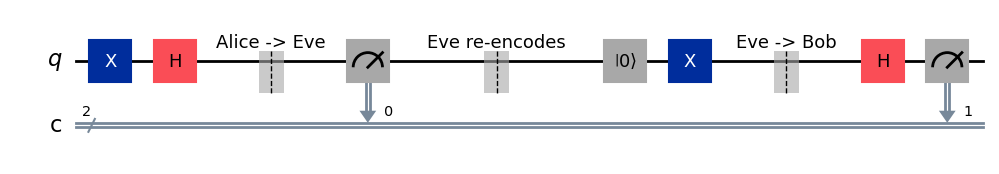

In [8]:
circuit = QuantumCircuit(1, 2)
# Alice encodes (bit=1, basis=X)
circuit.x(0)   # |1>
circuit.h(0)   # |1> -> |-> in X basis

circuit.barrier(label="Alice -> Eve")

# Eve intercepts and measures in Z basis
circuit.measure(0, 0)  # Eve measures into c[0]

circuit.barrier(label="Eve re-encodes")

# Reset the qubit to |0> to model Eve preparing a fresh qubit
circuit.reset(0)

# For this example circuit, assume Eve measured 1 and re-encodes bit=1 in Z basis.
# (In the full simulation, this depends on the actual measurement result.)
circuit.x(0)   # Eve encodes |1> in Z basis

circuit.barrier(label="Eve -> Bob")

# Bob measures in X basis
circuit.h(0)       # rotate to X basis
circuit.measure(0, 1)  # Bob's result in c[1]

circuit.draw("mpl")